# Simulate a sky background with realistic background galaxies and Milky Way stars

This notebook shows how to generate a sky background model including background galaxies and MW stars. You are encouraged to use the script at `rosesim/scripts/sim_sky.py`. 

In [161]:
# Import packages
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS

import os, sys
sys.path.append('/home/jiaxuanl/Research/Packages/romanisim/')
os.chdir('/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [164]:
import asdf
from astroquery.gaia import Gaia
from astropy.coordinates import SkyCoord
from astropy.time import Time
from astropy.table import Table, vstack, Column, hstack
from astropy import units as u
from astropy.visualization import simple_norm
import copy
import galsim
import roman_datamodels as rdm
import romanisim
from romanisim import gaia, bandpass, catalog, log, wcs, persistence, parameters, ris_make_utils as ris
from romanisim.image import inject_sources_into_l2
from romanisim.l3 import inject_sources_into_l3

## 1. Load JAGUAR background galaxies. 

JAGUAR is a simulated galaxy catalog, designed for JWST work. See here for more details: https://fenrir.as.arizona.edu/jaguar/download_jaguar_files.html

The catalog needs to be requested from that website. You can email me if you really want to use this catalog. 

In [165]:
# cat_Q = Table.read("/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/JAGUAR/JADES_Q_mock_r1_v1.2.fits")
# cat_SF = Table.read("/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/JAGUAR/JADES_SF_mock_r1_v1.2.fits")
# cat_all = vstack([cat_Q, cat_SF])
# cat_all = cat_all[(cat_all['sersic_n'] < 6) & (cat_all['sersic_n'] > 0.35)]
# cat_all.write('/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/JAGUAR/JADES_all_mock_r1_v1.2.fits')

## 2. Artpop and make catalogs for Romanisim

In [166]:
from kuaizi.display import display_single

In [167]:
import os
os.environ['NUMEXPR_MAX_THREADS'] = "30"
os.environ['ROSESIM_DATA_PATH'] = "/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/"

import artpop
import rosesim
from rosesim.rose import RomanGalaxy, RomanSky
rng = np.random.RandomState(100)

In [168]:
# This location is centered at NGC 253
# The MW stars from TRILEGAL are actually around this location.
obs_ra, obs_dec = 11.8880580, -25.2888000 # NGC 253

In [169]:
s = 501 # size of the frame
sky = RomanSky(obs_ra, obs_dec, xy_dim=np.array([s, s]), prefix='sky_jaguar_test')
radius = sky.xy_dim[0] * 0.11 / 3600
sky.obs_time = Time('2026-01-01T00:00:00') # this will affect the sky background level
# sky.load_gaia_star(radius=radius)
sky.load_trilegal_star(radius=radius, area=2, 
                       path='/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/TRILEGAL/trilegal_Roman_30mag_2deg2_NGC253.dat')
sky.load_jaguar_bkg(radius=radius, seed=42)
sky.gen_catalog(include_bkg=False, include_star=True)

Warning -- need to figure out the coefficients between JWST and Roman filters.
5 star sources loaded.


In [158]:
exptime = 642 # HLWAS
sky.observe('F158', exptime=exptime, fastpointsources=True, psftype='galsim')
# sky.observe('F106', exptime=exptime)
# sky.observe('F129', exptime=exptime)

Making mock Roman L3 image in F158 for sky_jaguar_test


2026-01-26 15:47:11 INFO     Running with args: Namespace(filename='/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim//sky_jaguar_test/F158_642s.asdf', catalog='/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim//sky_jaguar_test/temp/sky_table_sky_jaguar_test.ecsv', bandpass='F158', config=None, date='2025-01-01T00:00:00.000', radec=[11.888058, -25.2888], npix=501, pixscalefrac=1.0, exptime=642.0, effreadnoise=None, nexposures=6.0, rng_seed=0, psftype='galsim', fastpointsources=True)
2026-01-26 15:47:11 INFO     Starting simulation...


2026-01-26 15:47:12 WARNING  Velocity aberration scale must be a positive number: -999999.0
2026-01-26 15:47:12 WARNING  Defaulting to scale of 1.0
2026-01-26 15:47:12 INFO     Simulating filter F158...


2026-01-26 15:47:12 INFO     Setting pixscale to match default.
2026-01-26 15:47:12 WARNING  wcs is None; unlikely to get orientation of PSF correct.
2026-01-26 15:47:12 INFO     Creating PSF using galsim


2026-01-26 15:47:12 WARNING  wcs is None; unlikely to get orientation of PSF correct.
2026-01-26 15:47:12 INFO     Creating PSF using galsim


2026-01-26 15:47:12 WARNING  wcs is None; unlikely to get orientation of PSF correct.
2026-01-26 15:47:12 INFO     Creating PSF using galsim


2026-01-26 15:47:13 WARNING  wcs is None; unlikely to get orientation of PSF correct.
2026-01-26 15:47:13 INFO     Creating PSF using galsim


2026-01-26 15:47:13 WARNING  No RNG set, constructing a new default RNG from default seed.
2026-01-26 15:47:13 INFO     Adding 25 sources to image...


2026-01-26 15:49:13 INFO     Rendered 25 point sources in 0.0154 seconds
2026-01-26 15:49:13 INFO     Rendered 25 total sources in 0.0161 seconds
2026-01-26 15:49:13 INFO     Simulation complete.


In [39]:
from galsim import roman
psf = roman.getPSF(2, 'H158', pupil_bin=8, n_waves=10)

In [69]:
from romanisim.l3 import l3_psf
var_psf = l3_psf('H158', 1, psftype='epsf',
        chromatic=False, variable=True, date=Time('2025-01-01T00:00:00'))
psf = l3_psf('H158', 1, psftype='epsf',
        chromatic=False, variable=False, date=Time('2025-01-01T00:00:00'))

In [112]:
temp = var_psf.at_position(10, 10)

In [114]:
var_psf.build_epsf_interpolator(image)

In [111]:
psf.draw_epsf(10, 10)

AttributeError: 'InterpolatedImage' object has no attribute 'draw_epsf'

In [95]:
temp = var_psf.at_position(10, 10)

0.11


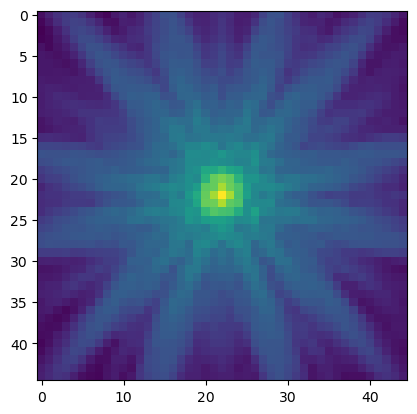

In [97]:
import galsim
import romanisim
print(romanisim.parameters.pixel_scale)

scale = romanisim.parameters.pixel_scale
nx = ny = (int(5 / scale) // 2) * 2 + 1

var_img = temp.drawImage(nx=nx, ny=ny, scale=scale, method="auto")  # auto chooses real/k-space wisely
var_img /= var_img.array.sum()

img = psf.drawImage(nx=nx, ny=ny, scale=scale, method="auto")  # auto chooses real/k-space wisely
img /= img.array.sum()

plt.imshow(np.log10(img.array))

In [105]:
maggytoes = romanisim.bandpass.get_abflux('F158', 2)

In [106]:
642 * maggytoes

np.float64(22662392080044.67)

In [107]:
maggytoes

np.float64(35299676137.141235)

In [11]:
from romanisim import ris_make_utils as ris
from romanisim import log, wcs, persistence, parameters, l3, bandpass, util

In [13]:
center = util.celestialcoord(SkyCoord(ra=0 * u.deg, dec=0 * u.deg))

In [62]:
cat = ris.create_catalog(metadata=None,
                         catalog_name='/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim//sky_jaguar_test/temp/sky_table_sky_jaguar_test.ecsv',
                         bandpasses=['F158'], coord=center, 
                         radius=501)

In [63]:
cat[0].profile.spectral

AttributeError: 'Row' object has no attribute 'profile'

In [27]:
center

coord.CelestialCoord(coord.Angle(0.0, coord.radians), coord.Angle(0.0, coord.radians))

'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim'

In [159]:
dm = rosesim.read_L3_asdf('./F158_642s.asdf')
# rosesim.utils.asdf_to_fits(dm, 'F158_642s.fits', subtract_bkg=False)

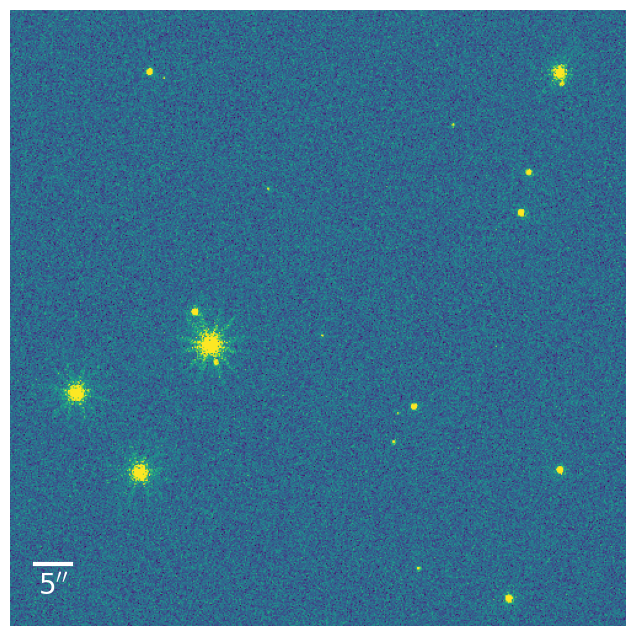

In [160]:
display_single(dm.data);

## 3. Visualize the sky background

In [47]:
from astropy.visualization import make_lupton_rgb

In [190]:
zp = -2.5 * np.log10(1 * ((0.11 * u.arcsec)**2).to(u.steradian).value * 1e6 / 3631)
print(zp)

25.265227862373404


In [202]:
os.chdir('../sky_jaguar_trilegal/')
os.chdir('../empty_sky/')
# os.chdir('../sky_jaguar_trilegal_cena_sizecut/')
os.chdir('../sky_jaguar_trilegal_cena_backup/')

In [203]:
filters = ['F106', 'F129', 'F158']
imgs = []
exptime = 642
# exptime = 2568
# exptime = 2568 * 4
for filt in filters:
    af = asdf.open(f'./{filt}_{exptime}s.asdf')
    dm = rdm.open(af)
    img = dm.data - np.median(dm.data)
    img *= 10**(0.4 * (27 - zp))
    imgs.append(img[:, :])

In [204]:
# rosesim.utils.asdf_to_fits(dm, './test.fits', subtract_bkg=True)

In [205]:
pwd

'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_cena_backup'

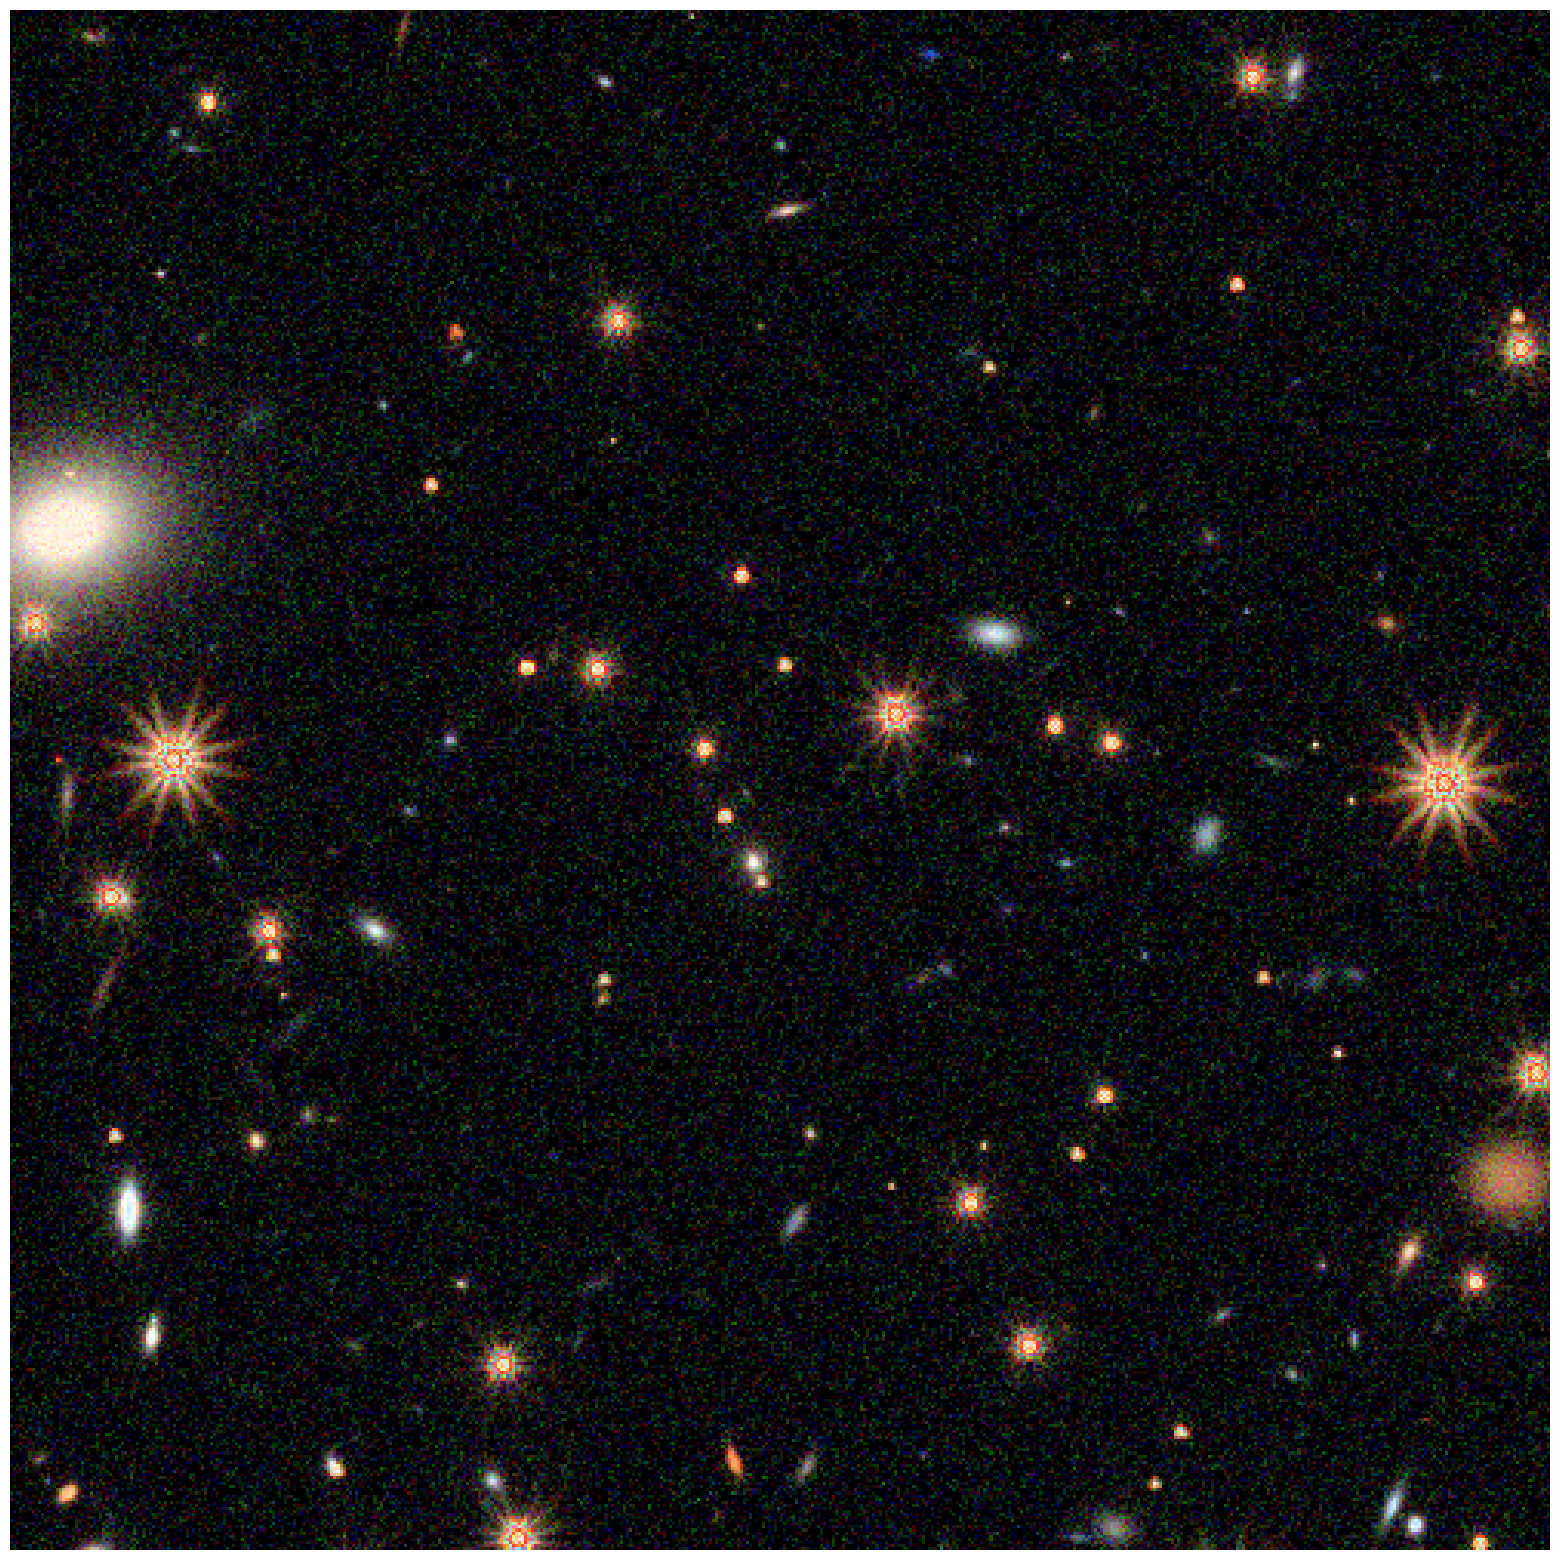

In [206]:
# rgb = make_lupton_rgb(1.0 * imgs[2], 1.05 * imgs[1], 1.2 * imgs[0], minimum=-0.03, stretch=1, Q=4)
rgb = make_lupton_rgb(0.9 * imgs[2], 1.05 * imgs[1], 1.2 * imgs[0], minimum=-0.02, stretch=1, Q=3)
fig, ax = plt.subplots(figsize=(20, 20))
plt.imshow(rgb[:500, :500])
plt.axis('off')

plt.savefig(f'/tigress/jiaxuanl/public_html/figure/SBF/Rosesim/sky_jaguar_cena_stpsf_slow_{exptime}s.png', bbox_inches='tight', dpi=200, transparent=True)
# plt.close()

Check https://tigress-web.princeton.edu/~jiaxuanl/figure/SBF/Rosesim/sky.png

---

In [143]:
dm = rosesim.read_L3_asdf("/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar/F158_642s.asdf")

In [144]:
dm.meta

{'association': {'name': '?'}, 'cal_logs': <roman_datamodels.stnode.CalLogs object at 0x7f3ad447dae0>, 'cal_step': {'flux': 'COMPLETE', 'outlier_detection': 'COMPLETE', 'resample': 'COMPLETE', 'skymatch': 'COMPLETE'}, 'calibration_software_name': 'RomanCAL', 'calibration_software_version': '?', 'coadd_info': {'exposure_time': 642.0, 'individual_image_meta': None, 'max_exposure_time': 642.0, 'time_first': <Time object: scale='utc' format='mjd' value=60675.99628472222>, 'time_last': <Time object: scale='utc' format='mjd' value=60676.00371527778>, 'time_mean': <Time object: scale='utc' format='isot' value=2025-01-01T00:00:00.000>}, 'coordinates': {'reference_frame': 'ICRS'}, 'file_date': <FileDate object: scale='utc' format='isot' value=2020-01-01T00:00:00.000>, 'filename': 'F158_642s.asdf', 'individual_image_meta': {}, 'instrument': {'name': 'WFI', 'optical_element': 'F158'}, 'model_type': 'MosaicModel', 'observation': {'execution_plan': -999999, 'exposure': -999999, 'exposure_grouping':

In [22]:
gwcs = dm.meta.wcs

In [25]:
gwcs.footprint()

array([[150.02843971,   2.19769392],
       [150.02843161,   2.35050203],
       [150.18136839,   2.35050203],
       [150.18136029,   2.19769392]])

In [84]:
obs_ra / 15, obs_dec

(10.006993333333332, 2.2741)